 ## NoSQL: Movie recommendation

 Overview:

 We will store jsons in mongodb collection, and do some cleaning and preprocessing of these collections. We've also performed analysis on the data.
 
 For ML task, we will recommend movies based on similarity score(content based filtering).

 Also we will do regression using KNN to predict rating of a movie.

#### We have created 5 collections:

Movies: title, budget, overview, genre ids, keywords ids, cast ids, director ids etc.

Genres: unique genres with their ids

Keywords: unique keywords with their ids

Casts: unique cast members with their ids

Directors: unique directors with their ids

#### Connecting to MongoDB

In [62]:
import pymongo
import json
from pymongo import MongoClient

# Connect to MongoDB
client = pymongo.MongoClient('mongodb://my-mongo-container:27017')

# Create or connect to a database
db = client['movie_recommend']

In [63]:
db

Database(MongoClient(host=['my-mongo-container:27017'], document_class=dict, tz_aware=False, connect=True), 'movie_recommend')

#### Priting out the Collections

In [64]:
collections = db.list_collection_names()

# Print the list of collection names
for collection in collections:
    print(collection)

movies
casts
directors
keywords
genres


#### Copying Data to New DB

In this lab you will be working with the movie_db database, this will be used so that the updates are not reflected in the original database

In [65]:
db = client["movie_db"]

In [66]:
from pymongo import MongoClient

# creating copy db
new_db_name = "movie_db"
new_db = client[new_db_name]

# Access the source database
source_db_name = "movie_recommend"
source_db = client[source_db_name]

# Function to copy a collection
def copy_collection(source_collection, destination_collection):
    data = list(source_collection.find())
    if data:
        destination_collection.drop()
        destination_collection.insert_many(data)

# Get the list of collection names from the source database
collections = source_db.list_collection_names()

# Copy each collection to the new database
for collection_name in collections:
    source_collection = source_db[collection_name]
    destination_collection = new_db[collection_name]
    copy_collection(source_collection, destination_collection)

db = new_db

In [67]:
# Create or connect to collections
movies_collection = db['movies']
genres_collection = db['genres']
casts_collection = db['casts']
directors_collection = db['directors']
keywords_collection = db['keywords']
crew_collection = db['crew']  # New collection for crew members

#### Commented code: Code to load json files and storing them in mongodb collection. We'll already be doing this for students and provide the already stored files. They just have to load the collections in their DB

### Displaying few collections

In [68]:
# Display one movie from the collection
movie = movies_collection.find_one()
print(json.dumps(movie, indent=4, sort_keys=True, default=str))


{
    "_id": "65f86c5fcb058a9b3faaa081",
    "budget": 237000000,
    "cast_ids": [
        "65f86c61cb058a9b3faab344",
        "65f86c61cb058a9b3faab345",
        "65f86c61cb058a9b3faab346",
        "65f86c61cb058a9b3faab347",
        "65f86c61cb058a9b3faab348",
        "65f86c61cb058a9b3faab349",
        "65f86c61cb058a9b3faab34a",
        "65f86c61cb058a9b3faab34b",
        "65f86c61cb058a9b3faab34c",
        "65f86c61cb058a9b3faab34d",
        "65f86c61cb058a9b3faab34e",
        "65f86c61cb058a9b3faab34f",
        "65f86c61cb058a9b3faab350",
        "65f86c61cb058a9b3faab351",
        "65f86c61cb058a9b3faab352",
        "65f86c61cb058a9b3faab353",
        "65f86c61cb058a9b3faab354",
        "65f86c61cb058a9b3faab355",
        "65f86c61cb058a9b3faab356",
        "65f86c61cb058a9b3faab357",
        "65f86c61cb058a9b3faab358",
        "65f86c61cb058a9b3faab359",
        "65f86c61cb058a9b3faab35a",
        "65f86c61cb058a9b3faab35b",
        "65f86c61cb058a9b3faab35c",
        "65f86c6

In [69]:
# Display one genre from the collection
genre = genres_collection.find_one()
print(json.dumps(genre, indent=4, sort_keys=True, default=str))


{
    "_id": "65f86c37cb058a9b3faa7a18",
    "id": 28,
    "name": "Action"
}


In [70]:
# Display one director from the collection
director = directors_collection.find_one()
print(json.dumps(director, indent=4, sort_keys=True, default=str))


{
    "_id": "65f86c61cb058a9b3faab397",
    "credit_id": "52fe48009251416c750ac9c3",
    "department": "Directing",
    "gender": 2,
    "id": 2710,
    "job": "Director",
    "name": "James Cameron"
}


In [71]:
db.movies.count_documents({})


4803

In [72]:
source_db = client['movie_recommend']
print(source_db.list_collection_names())

['movies', 'casts', 'directors', 'keywords', 'genres']


### Q1. Cleaning Data
Remove any movies with missing information like genres, titles, or overviews. 

#### 1.1 Count the number of movies with missing information like genres, titles, or overviews. 

In [73]:
# TODO: YOUR CODE STARTS HERE
missing_count = movies_collection.count_documents({
    "$or": [
        {"genres_ids": {"$exists": False}},
        {"genres_ids": []},
        {"original_title": {"$exists": False}},
        {"original_title": ""},
        {"overview": {"$exists": False}},
        {"overview": ""}
    ]
})
print(f"Movies with missing information: {missing_count}")
# TODO: YOUR CODE ENDS HERE


Movies with missing information: 28


#### 1.2 Remove the records with missing genres

In [74]:
# TODO: YOUR CODE STARTS HERE
result = movies_collection.delete_many({
    "$or": [
        {"genres_ids": {"$exists": False}},
        {"genres_ids": []}
    ]
})
print(f"Deleted {result.deleted_count} movies with missing genres")
# TODO: YOUR CODE ENDS HERE


Deleted 28 movies with missing genres


In [75]:
db.movies.count_documents({})

4775

#### 1.3 Checking for duplicates

print count of distinct movies

In [76]:
# TODO: YOUR CODE STARTS HERE
distinct_count = len(movies_collection.distinct("original_title"))
print(f"Distinct movies: {distinct_count}")
# TODO: YOUR CODE ENDS HERE

Distinct movies: 4773


#### 1.4 Normalizing Popularity Scores
Normalize the popularity scores to a common scale, e.g., 0-1, to standardize comparison across movies.

- Hint

To normalize the popularity scores to a common scale, such as 0-1, and standardize comparison across movies, you can use the following formula:
normalized_popularity = (popularity - min popularity) / (max_popularity - min_popularity)

Create a new column normalized_popularity
- **normalized_popularity**: The normalized popularity score of the movie.
- **popularity**: The original popularity score of the movie.
- **min_popularity**: The minimum popularity score among all movies in the dataset.
- **max_popularity**: The maximum popularity score among all movies in the dataset.


In [77]:
# TODO: YOUR CODE STARTS HERE
# Find min and max popularity
min_popularity = movies_collection.find_one(sort=[("popularity", 1)])["popularity"]
max_popularity = movies_collection.find_one(sort=[("popularity", -1)])["popularity"]
print(f"Min popularity: {min_popularity}")
print(f"Max popularity: {max_popularity}")

# Update each document with normalized popularity
movies = movies_collection.find()
for movie in movies:
    normalized = (movie["popularity"] - min_popularity) / (max_popularity - min_popularity)
    movies_collection.update_one(
        {"_id": movie["_id"]},
        {"$set": {"normalized_popularity": normalized}}
    )

Min popularity: 0.000372
Max popularity: 875.581305


In [78]:
# Let's check a example movie if the normalized popularity is added
movie = movies_collection.find_one({"original_title": "Avatar"})
print(f"Popularity: {movie['popularity']}")
print(f"Normalized Popularity: {movie['normalized_popularity']}")

Popularity: 150.437577
Normalized Popularity: 0.17181416283764597


### Q2. Feature Engineering with Budget and Revenue
Create new feature profitability (revenue - budget)

In [79]:
# TODO: YOUR CODE STARTS HERE
# Add profitability field to each movie document (revenue - budget)
movies = movies_collection.find()
for movie in movies:
    profitability = movie["revenue"] - movie["budget"]
    movies_collection.update_one(
        {"_id": movie["_id"]},
        {"$set": {"profitability": profitability}}
    )
# TODO: YOUR CODE ENDS HERE


In [80]:
# Let's check a example movie if the profitability is added
movie = movies_collection.find_one({"original_title": "Avatar"})
print(f"Budget: {movie['budget']}")
print(f"Revenue: {movie['revenue']}")
print(f"Profitability: {movie['profitability']}")

Budget: 237000000
Revenue: 2787965087
Profitability: 2550965087


### Q3. Categorizing Release Dates
 Categorize movies by release year (create a new feature release year)

In [81]:
# TODO: YOUR CODE STARTS HERE
movies = movies_collection.find()
for movie in movies:
    release_date = movie.get("release_date", "")
    if release_date:
        release_year = int(release_date[:4])  # extract first 4 chars = year
    else:
        release_year = None
    movies_collection.update_one(
        {"_id": movie["_id"]},
        {"$set": {"release_year": release_year}}
    )
# TODO: YOUR CODE ENDS HERE

In [82]:
# Let's check a example movie if the release year is added
movie = movies_collection.find_one({"original_title": "Avatar"})
print(f"Release date: {movie['release_date']}")
print(f"Release year: {movie['release_year']}")

Release date: 2009-12-10
Release year: 2009


### Q4. Analysis

### 4.1 Most Popular Genres

Store the result and print out the Top 10 genres that are most popular based on the number of movies and average popularity scores.

- **Hint:** You might require `$unwind`, `$lookup`, `$group`, and `$sort`, `$limit` operations for this task.


In [83]:
# TODO: YOUR CODE STARTS HERE

# There was issue with genres_ids being stored as strings, we need to convert them to ObjectId for lookup

# Import ObjectId for converting genre IDs to ObjectId type
from bson import ObjectId

# Find top 10 genres by number of movies and average popularity
pipeline = [
    {"$unwind": "$genres_ids"},
    {"$addFields": {
        "genres_ids_obj": {"$toObjectId": "$genres_ids"}
    }},
    {"$lookup": {
        "from": "genres",
        "localField": "genres_ids_obj",
        "foreignField": "_id",
        "as": "genre_info"
    }},
    {"$unwind": "$genre_info"},
    {"$group": {
        "_id": "$genre_info.name",
        "num_movies": {"$sum": 1},
        "avg_popularity": {"$avg": "$popularity"}
    }},
    {"$sort": {"num_movies": -1}},
    {"$limit": 10}
]

top_genres = list(movies_collection.aggregate(pipeline))
for genre in top_genres:
    print(genre)

# TODO: YOUR CODE ENDS HERE


{'_id': 'Drama', 'num_movies': 2297, 'avg_popularity': 17.764853371789293}
{'_id': 'Comedy', 'num_movies': 1722, 'avg_popularity': 18.221000988966317}
{'_id': 'Thriller', 'num_movies': 1274, 'avg_popularity': 24.46007652511774}
{'_id': 'Action', 'num_movies': 1154, 'avg_popularity': 30.940382153379552}
{'_id': 'Romance', 'num_movies': 894, 'avg_popularity': 15.962426457494407}
{'_id': 'Adventure', 'num_movies': 790, 'avg_popularity': 39.26804199113924}
{'_id': 'Crime', 'num_movies': 696, 'avg_popularity': 22.853274340517242}
{'_id': 'Science Fiction', 'num_movies': 535, 'avg_popularity': 36.451805871028036}
{'_id': 'Horror', 'num_movies': 519, 'avg_popularity': 18.29591510404624}
{'_id': 'Family', 'num_movies': 513, 'avg_popularity': 27.8328489122807}


#### Q4.2 Plot the barplot between the number of movies and the top 10 genres

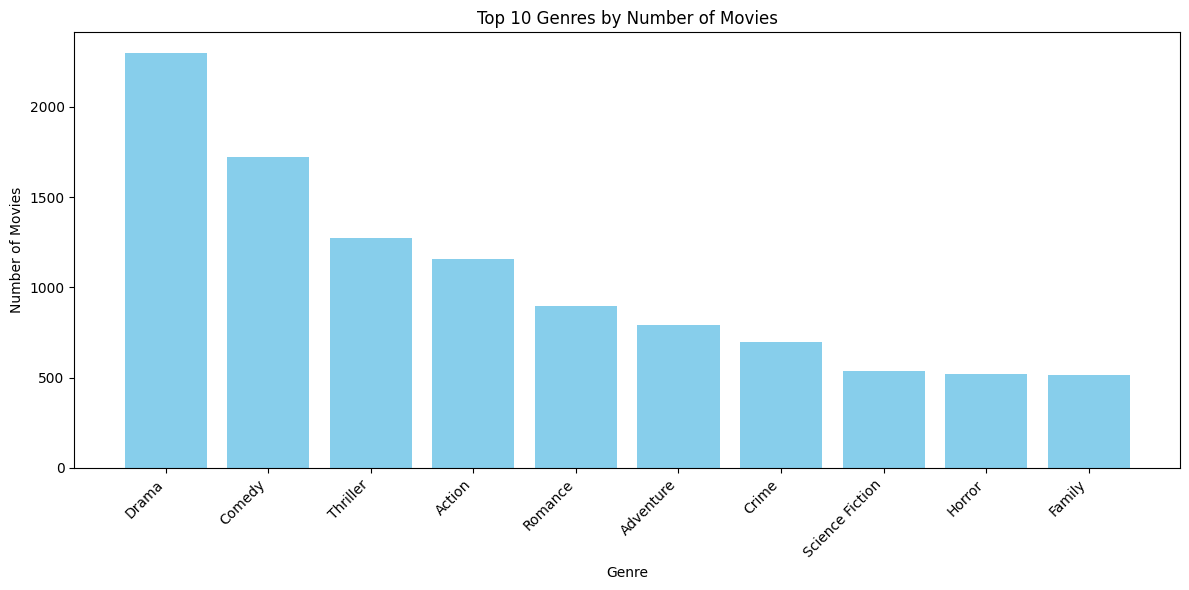

In [84]:
# TODO: YOUR CODE STARTS HERE
import matplotlib.pyplot as plt

genres = [genre['_id'] for genre in top_genres]
num_movies = [genre['num_movies'] for genre in top_genres]

plt.figure(figsize=(12, 6))
plt.bar(genres, num_movies, color='skyblue')
plt.xlabel('Genre')
plt.ylabel('Number of Movies')
plt.title('Top 10 Genres by Number of Movies')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()
# TODO: YOUR CODE ENDS HERE

#### 4.3 Top Directors by Revenue
Find top 10 directors whose movies have generated the most revenue, indicating their commercial success.

- **Hint:** You might require `$unwind`, `$lookup`, `$group`, and `$sort`, `$limit` operations for this task.


In [85]:
# TODO: YOUR CODE STARTS HERE
pipeline = [
    {"$unwind": "$director_ids"},
    {"$addFields": {
        "director_ids_obj": {"$toObjectId": "$director_ids"}
    }},
    {"$lookup": {
        "from": "directors",
        "localField": "director_ids_obj",
        "foreignField": "_id",
        "as": "director_info"
    }},
    {"$unwind": "$director_info"},
    {"$group": {
        "_id": "$director_info.name",
        "total_revenue": {"$sum": "$revenue"},
        "num_movies": {"$sum": 1}
    }},
    {"$sort": {"total_revenue": -1}},
    {"$limit": 10}
]

top_directors = list(movies_collection.aggregate(pipeline))
for director in top_directors:
    print(director)
# TODO: YOUR CODE ENDS HERE


{'_id': 'Steven Spielberg', 'total_revenue': 9147393164, 'num_movies': 27}
{'_id': 'Peter Jackson', 'total_revenue': 6498642820, 'num_movies': 9}
{'_id': 'James Cameron', 'total_revenue': 5883569439, 'num_movies': 7}
{'_id': 'Michael Bay', 'total_revenue': 5832524638, 'num_movies': 12}
{'_id': 'Christopher Nolan', 'total_revenue': 4227483234, 'num_movies': 8}
{'_id': 'Chris Columbus', 'total_revenue': 3725631503, 'num_movies': 11}
{'_id': 'Robert Zemeckis', 'total_revenue': 3590622002, 'num_movies': 13}
{'_id': 'George Lucas', 'total_revenue': 3339113893, 'num_movies': 5}
{'_id': 'Tim Burton', 'total_revenue': 3337418241, 'num_movies': 14}
{'_id': 'Ridley Scott', 'total_revenue': 3189557997, 'num_movies': 16}


#### 4.4 Most profitable movies
Print top 10 movies showing there budget, revenue, title and profit

- **Hint:** You might require `$project`, `$sort` operations for this task.


In [86]:
# TODO: YOUR CODE STARTS HERE
pipeline = [
    {"$project": {
        "title": "$original_title",
        "budget": 1,
        "revenue": 1,
        "profit": "$profitability"
    }},
    {"$sort": {"profit": -1}},
    {"$limit": 10}
]

most_profitable = list(movies_collection.aggregate(pipeline))
for movie in most_profitable:
    print(movie)
# TODO: YOUR CODE ENDS HERE


{'_id': ObjectId('65f86c5fcb058a9b3faaa081'), 'budget': 237000000, 'revenue': 2787965087, 'title': 'Avatar', 'profit': 2550965087}
{'_id': ObjectId('65f86c5fcb058a9b3faaa09a'), 'budget': 200000000, 'revenue': 1845034188, 'title': 'Titanic', 'profit': 1645034188}
{'_id': ObjectId('65f86c5fcb058a9b3faaa09d'), 'budget': 150000000, 'revenue': 1513528810, 'title': 'Jurassic World', 'profit': 1363528810}
{'_id': ObjectId('65f86c5fcb058a9b3faaa0ad'), 'budget': 190000000, 'revenue': 1506249360, 'title': 'Furious 7', 'profit': 1316249360}
{'_id': ObjectId('65f86c5fcb058a9b3faaa091'), 'budget': 220000000, 'revenue': 1519557910, 'title': 'The Avengers', 'profit': 1299557910}
{'_id': ObjectId('65f86c5fcb058a9b3faaa088'), 'budget': 280000000, 'revenue': 1405403694, 'title': 'Avengers: Age of Ultron', 'profit': 1125403694}
{'_id': ObjectId('65f86c5fcb058a9b3faaa0fd'), 'budget': 150000000, 'revenue': 1274219009, 'title': 'Frozen', 'profit': 1124219009}
{'_id': ObjectId('65f86c5fcb058a9b3faaa2a3'), 'b

#### 4.5 Average Rating by Genre
Determine the average user rating for movies within each genre to see which genres are most critically acclaimed.

In [87]:
# TODO: YOUR CODE STARTS HERE
pipeline = [
    {"$unwind": "$genres_ids"},
    {"$addFields": {
        "genres_ids_obj": {"$toObjectId": "$genres_ids"}
    }},
    {"$lookup": {
        "from": "genres",
        "localField": "genres_ids_obj",
        "foreignField": "_id",
        "as": "genre_info"
    }},
    {"$unwind": "$genre_info"},
    {"$group": {
        "_id": "$genre_info.name",
        "avg_rating": {"$avg": "$vote_average"}
    }},
    {"$sort": {"avg_rating": -1}}
]

avg_rating_by_genre = list(movies_collection.aggregate(pipeline))
for genre in avg_rating_by_genre:
    print(genre)
# TODO: YOUR CODE ENDS HERE


{'_id': 'History', 'avg_rating': 6.71979695431472}
{'_id': 'War', 'avg_rating': 6.713888888888889}
{'_id': 'Drama', 'avg_rating': 6.388593818023509}
{'_id': 'Music', 'avg_rating': 6.355675675675675}
{'_id': 'Foreign', 'avg_rating': 6.352941176470588}
{'_id': 'Animation', 'avg_rating': 6.341452991452992}
{'_id': 'Crime', 'avg_rating': 6.274137931034483}
{'_id': 'Documentary', 'avg_rating': 6.238181818181818}
{'_id': 'Romance', 'avg_rating': 6.207718120805369}
{'_id': 'Mystery', 'avg_rating': 6.183908045977011}
{'_id': 'Western', 'avg_rating': 6.1780487804878055}
{'_id': 'Adventure', 'avg_rating': 6.156962025316456}
{'_id': 'Fantasy', 'avg_rating': 6.096698113207547}
{'_id': 'Family', 'avg_rating': 6.029629629629629}
{'_id': 'Thriller', 'avg_rating': 6.010989010989011}
{'_id': 'Science Fiction', 'avg_rating': 6.005607476635514}
{'_id': 'Action', 'avg_rating': 5.989514731369151}
{'_id': 'Comedy', 'avg_rating': 5.945586527293844}
{'_id': 'TV Movie', 'avg_rating': 5.6625}
{'_id': 'Horror', 

## Q5 Movie Recommendation

### Content based filtering

Recommend movies based on similarity score


In [88]:
movies = list(db.movies.find())

In [89]:
db.movies.find_one()

{'_id': ObjectId('65f86c5fcb058a9b3faaa081'),
 'original_title': 'Avatar',
 'id': 19995,
 'genres_ids': [ObjectId('65f86c37cb058a9b3faa7a18'),
  ObjectId('65f86c37cb058a9b3faa7a19'),
  ObjectId('65f86c37cb058a9b3faa7a1a'),
  ObjectId('65f86c37cb058a9b3faa7a1b')],
 'keywords_ids': [ObjectId('65f86c37cb058a9b3faa7a1c'),
  ObjectId('65f86c37cb058a9b3faa7a1d'),
  ObjectId('65f86c37cb058a9b3faa7a1e'),
  ObjectId('65f86c37cb058a9b3faa7a1f'),
  ObjectId('65f86c37cb058a9b3faa7a20'),
  ObjectId('65f86c37cb058a9b3faa7a21'),
  ObjectId('65f86c37cb058a9b3faa7a22'),
  ObjectId('65f86c37cb058a9b3faa7a23'),
  ObjectId('65f86c37cb058a9b3faa7a24'),
  ObjectId('65f86c37cb058a9b3faa7a25'),
  ObjectId('65f86c37cb058a9b3faa7a26'),
  ObjectId('65f86c37cb058a9b3faa7a27'),
  ObjectId('65f86c37cb058a9b3faa7a28'),
  ObjectId('65f86c37cb058a9b3faa7a29'),
  ObjectId('65f86c37cb058a9b3faa7a2a'),
  ObjectId('65f86c37cb058a9b3faa7a2b'),
  ObjectId('65f86c37cb058a9b3faa7a2c'),
  ObjectId('65f86c37cb058a9b3faa7a2d'),


### Feature Creation from Collections

#### 5.1 Complete the function below to fetch values from IDs for genres, keywords, casts, and directors

In [90]:
# TODO: YOUR CODE STARTS HERE
def get_names_from_ids(collection, ids):
    names = []
    for id in ids:
        doc = collection.find_one({"_id": id})
        if doc:
            names.append(doc["name"])
    return names
# TODO: YOUR CODE ENDS HERE

In [91]:
# Let's test with Avatar's genres
avatar = movies_collection.find_one({"original_title": "Avatar"})
genre_names = get_names_from_ids(genres_collection, avatar["genres_ids"])
print(genre_names)

['Action', 'Adventure', 'Fantasy', 'Science Fiction']


### 5.2 Combine Movie Features into a Single String

Combine the following features for each movie into a single string and create a new attribute features

- **Genres:** Combine the names of genres associated with the movie.
- **Keywords:** Combine the names of keywords associated with the movie.
- **Top 5 Cast Members:** Combine the names of the top 5 cast members associated with the movie.
- **Director:** Combine the name of the director associated with the movie.
- **Overview Text:** Append the overview text of the movie.


In [92]:
# TODO: YOUR CODE STARTS HERE
combined_features = []

for movie in movies:
    # Get names from IDs
    genres = get_names_from_ids(genres_collection, movie.get("genres_ids", []))
    keywords = get_names_from_ids(keywords_collection, movie.get("keywords_ids", []))
    cast = get_names_from_ids(casts_collection, movie.get("cast_ids", []))[:5]  # top 5 only
    directors = get_names_from_ids(directors_collection, movie.get("director_ids", []))
    overview = movie.get("overview", "") or ""

    # Combine everything into one string
    features = " ".join(genres) + " " + " ".join(keywords) + " " + " ".join(cast) + " " + " ".join(directors) + " " + overview

    combined_features.append(features)

# TODO: YOUR CODE ENDS HERE

In [93]:
combined_features

['Action Adventure Fantasy Science Fiction culture clash future space war space colony society space travel futuristic romance space alien tribe alien planet cgi marine soldier battle love affair anti war power relations mind and soul 3d Sam Worthington Zoe Saldana Sigourney Weaver Stephen Lang Michelle Rodriguez James Cameron In the 22nd century, a paraplegic Marine is dispatched to the moon Pandora on a unique mission, but becomes torn between following orders and protecting an alien civilization.',
 "Adventure Fantasy Action ocean drug abuse exotic island east india trading company love of one's life traitor shipwreck strong woman ship alliance calypso afterlife fighter pirate swashbuckler aftercreditsstinger Johnny Depp Orlando Bloom Keira Knightley Stellan Skarsgård Chow Yun-fat Gore Verbinski Captain Barbossa, long believed to be dead, has come back to life and is headed to the edge of the Earth with Will Turner and Elizabeth Swann. But nothing is quite as it seems.",
 'Action Ad

### 5.3 Remove stop words from the feature column and create feature matrix using vectorizer

Stop words are frequently occurring, low-meaning words (e.g., "the," "is," "and") filtered out during NLP pre-processing to reduce noise, enhance computational efficiency, and focus on meaningful content. Use TfidfVectorizer of sklearn to ignore stop words.

In [94]:
# TODO: YOUR CODE STARTS HERE

from sklearn.feature_extraction.text import TfidfVectorizer

# Remove stop words and create feature matrix
tfidf = TfidfVectorizer(stop_words='english')
feature_matrix = tfidf.fit_transform(combined_features)

print(f"Feature matrix shape: {feature_matrix.shape}")
# TODO: YOUR CODE ENDS HERE



Feature matrix shape: (4775, 30892)


### 5.4 Perform cosine similarity on the generated feature matrix

In [95]:
# TODO: YOUR CODE STARTS HERE

from sklearn.metrics.pairwise import cosine_similarity

cosine_sim = cosine_similarity(feature_matrix, feature_matrix)

print(f"Cosine similarity matrix shape: {cosine_sim.shape}")
# TODO: YOUR CODE ENDS HERE

Cosine similarity matrix shape: (4775, 4775)


In [96]:
cosine_sim

array([[1.        , 0.01647769, 0.01553918, ..., 0.00431197, 0.00643143,
        0.        ],
       [0.01647769, 1.        , 0.00704139, ..., 0.        , 0.01284628,
        0.        ],
       [0.01553918, 0.00704139, 1.        , ..., 0.        , 0.00813212,
        0.        ],
       ...,
       [0.00431197, 0.        , 0.        , ..., 1.        , 0.00616757,
        0.        ],
       [0.00643143, 0.01284628, 0.00813212, ..., 0.00616757, 1.        ,
        0.02135215],
       [0.        , 0.        , 0.        , ..., 0.        , 0.02135215,
        1.        ]])

### 5.5 Complete the recommend_movies function which takes the title of the movie and cosine similarity matrix as input in the argument

The function should return the Top 10 recommendations for the movie passed in the argument(return Title and Similarity scores)

Hint: Use the title to get the index of the movie, use that to get the similarity scores of the movie from the cosine_sim matrix and return the top 10 similar movies


In [97]:
# TODO: YOUR CODE STARTS HERE

# Import pandas for better visualization of similarity matrix
import pandas as pd

# TODO: YOUR CODE ENDS HERE

In [98]:
# TODO: YOUR CODE STARTS HERE

# Create a series mapping movie titles to their index
movies_df = pd.DataFrame(movies)
indices = pd.Series(movies_df.index, index=movies_df['original_title'])

def recommend_movies(title, cosine_sim=cosine_sim):
    # Get index of the movie
    idx = indices[title]
    
    # Get similarity scores for all movies with this movie
    sim_scores = list(enumerate(cosine_sim[idx]))
    
    # Sort by similarity score descending
    sim_scores = sorted(sim_scores, key=lambda x: x[1], reverse=True)
    
    # Get top 10 (skip index 0 which is the movie itself)
    sim_scores = sim_scores[1:11]
    
    # Get movie indices and scores
    movie_indices = [i[0] for i in sim_scores]
    similarity_scores = [i[1] for i in sim_scores]
    
    # Return titles and scores
    return pd.DataFrame({
        'title': movies_df['original_title'].iloc[movie_indices].values,
        'similarity_score': similarity_scores
    })



# TODO: YOUR CODE ENDS HERE


### 5.6 Display Results of recommendation

In [99]:
# TODO: YOUR CODE STARTS HERE
print(recommend_movies("Avatar"))
# TODO: YOUR CODE ENDS HERE

                title  similarity_score
0              Aliens          0.290574
1              Alien³          0.264153
2           Moonraker          0.240329
3     Mission to Mars          0.236203
4               Alien          0.234888
5     Treasure Planet          0.215971
6             Lockout          0.215754
7          Spaceballs          0.215206
8           Lifeforce          0.209031
9  Planet of the Apes          0.205286


In [100]:
# TODO: YOUR CODE STARTS HERE
print(recommend_movies("Inception"))
# TODO: YOUR CODE ENDS HERE

                                title  similarity_score
0                             Don Jon          0.103425
1                 The Helix... Loaded          0.102420
2                              Cypher          0.096958
3                (500) Days of Summer          0.095155
4                              Hesher          0.091653
5                      Blood and Wine          0.076737
6                       Heartbreakers          0.076349
7                            The East          0.075655
8  Mission: Impossible - Rogue Nation          0.075472
9                              Looper          0.072761


In [101]:
# TODO: YOUR CODE STARTS HERE
print(recommend_movies("The Dark Knight"))
# TODO: YOUR CODE ENDS HERE

                                     title  similarity_score
0                    The Dark Knight Rises          0.443962
1                            Batman Begins          0.365376
2                           Batman Returns          0.343968
3                           Batman Forever          0.308085
4                                   Batman          0.289365
5  Batman: The Dark Knight Returns, Part 2          0.261784
6       Batman v Superman: Dawn of Justice          0.228844
7                           Batman & Robin          0.218074
8                                 Kick-Ass          0.153383
9                      Law Abiding Citizen          0.147335


## Q6 Predict Rating(vote_average) of the movie

#### 6.1 Creating feature matrix
- Similar to what we did in 5.2, now we will create a feature matrix for each movie where we will have the same combined features column string and apart from that we will also include the popularity and the budget in our features.
- vote average will be our label column

In [102]:
# TODO: YOUR CODE STARTS HERE

movies_df['combined_features'] = combined_features
movies_df['popularity'] = [movie.get('popularity', 0) for movie in movies]
movies_df['budget'] = [movie.get('budget', 0) for movie in movies]

y = movies_df['vote_average'].fillna(0)

print(movies_df[['original_title', 'combined_features', 'popularity', 'budget', 'vote_average']].head())

# TODO: YOUR CODE ENDS HERE


                             original_title  \
0                                    Avatar   
1  Pirates of the Caribbean: At World's End   
2                                   Spectre   
3                     The Dark Knight Rises   
4                               John Carter   

                                   combined_features  popularity     budget  \
0  Action Adventure Fantasy Science Fiction cultu...  150.437577  237000000   
1  Adventure Fantasy Action ocean drug abuse exot...  139.082615  300000000   
2  Action Adventure Crime spy based on novel secr...  107.376788  245000000   
3  Action Crime Drama Thriller dc comics crime fi...  112.312950  250000000   
4  Action Adventure Science Fiction based on nove...   43.926995  260000000   

   vote_average  
0           7.2  
1           6.9  
2           6.3  
3           7.6  
4           6.1  


#### 6.2 Perform vectorization on text feature and  standard scaling on the numerical features


In [103]:
# TODO: YOUR CODE STARTS HERE
from sklearn.preprocessing import StandardScaler

# Vectorize text features
tfidf_q6 = TfidfVectorizer(stop_words='english')
X = tfidf_q6.fit_transform(movies_df['combined_features'].fillna(''))

# Scale numerical features (kept separate, not combined)
scaler = StandardScaler()
numerical_scaled = scaler.fit_transform(movies_df[['popularity', 'budget']].fillna(0))

print(f"Text feature matrix shape: {X.shape}")
print(f"Numerical feature matrix shape: {numerical_scaled.shape}")

# TODO: YOUR CODE ENDS HERE

Text feature matrix shape: (4775, 30892)
Numerical feature matrix shape: (4775, 2)


#### 6.3 Linear Regression on Vote Average
- Split the data into training and test set
- Perform linear regression
- Calculate mean square error

In [104]:
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error
import numpy as np

In [105]:
# TODO: YOUR CODE STARTS HERE

# Split data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Train model
model = LinearRegression()
model.fit(X_train, y_train)

# Predict
y_pred = model.predict(X_test)

# RMSE
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
print(f"RMSE: {rmse:.2f}")
# TODO: YOUR CODE ENDS HERE

RMSE: 1.15


In [106]:
y.describe()

count    4775.000000
mean        6.114199
std         1.140636
min         0.000000
25%         5.600000
50%         6.200000
75%         6.800000
max        10.000000
Name: vote_average, dtype: float64

The model's error is about equal to the standard deviation, meaning it's not much better than just predicting the mean every time. Moderate performance.

#### 6.4 Complete the predict vote average function
- The funtion takes movie tittle as argument
- The function should return the vote average for the movie

In [107]:
# TODO: YOUR CODE STARTS HERE

def predict_vote_average(title):
    # Get the movie's combined features
    movie = movies_df[movies_df['original_title'] == title]
    
    if movie.empty:
        return f"Movie '{title}' not found"
    
    # Transform the features
    features = tfidf_q6.transform(movie['combined_features'].fillna(''))
    
    # Predict
    predicted_rating = model.predict(features)[0]
    
    return round(predicted_rating, 2)
# TODO: YOUR CODE ENDS HERE



#### 6.5 Display the average rating

Display the average rating of the movies "Avatar", "Inception", and "Gulliver's Travels"

In [108]:
# TODO: YOUR CODE STARTS HERE
print(f"Avatar predicted rating: {predict_vote_average('Avatar')}")
# TODO: YOUR CODE ENDS HERE

Avatar predicted rating: 7.2


In [109]:
# TODO: YOUR CODE STARTS HERE
print(f"Inception predicted rating: {predict_vote_average('Inception')}")
# TODO: YOUR CODE ENDS HERE

Inception predicted rating: 6.98


In [110]:
# TODO: YOUR CODE STARTS HERE
gulliver = "Gulliver's Travels"
print(f"Gulliver's Travels predicted rating: {predict_vote_average(gulliver)}")
# TODO: YOUR CODE ENDS HERE

Gulliver's Travels predicted rating: 6.34
